<a href="https://colab.research.google.com/github/eegicheck-hehe/test_git_DigitalProject_DAAI/blob/main/MyFirstModel%5E%5E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub # Download latest version
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
print("Path to dataset files:", path)

import os

print(os.listdir(path))

import pandas as pd

df = pd.read_csv(path + '/Mental_Health_and_Social_Media_Balance_Dataset.csv')
print(df)

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


100%|██████████| 5.80k/5.80k [00:00<00:00, 2.87MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prince7489/mental-health-and-social-media-balance-dataset/versions/1
['Mental_Health_and_Social_Media_Balance_Dataset.csv']


    User_ID  Age  Gender  Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  \
0      U001   44    Male                     3.1                  7.0   
1      U002   30   Other                     5.1                  7.0   
2      U003   23   Other                     7.4                  6.0   
3      U004   36  Female                     5.7                  7.0   
4      U005   34  Female                     7.0                  4.0   
..      ...  ...     ...                     ...                  ...   
495    U496   23    Male                     6.9                  5.0   
496    U497   43  Female                     5.6                  7.0   
497    U498   41    Male                     7.7                  5.0   
498    U499   23    Male                     4.2                  9.0   
499    U500   43  Female                     5.9                  5.0   

     Stress_Level(1-10)  Days_Without_Social_Media  Exercise_Frequency(week)  \
0                   6.0                    

data_type:
 User_ID                       object
Age                            int64
Gender                        object
Daily_Screen_Time(hrs)       float64
Sleep_Quality(1-10)          float64
Stress_Level(1-10)           float64
Days_Without_Social_Media    float64
Exercise_Frequency(week)     float64
Social_Media_Platform         object
Happiness_Index(1-10)        float64
dtype: object 

пропуски:
 User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64 

описание
        User_ID         Age Gender  Daily_Screen_Time(hrs)  \
count      500  500.000000    500              500.000000   
unique     500         NaN      3                     NaN   
top       U500         NaN   Male                     NaN   
freq        

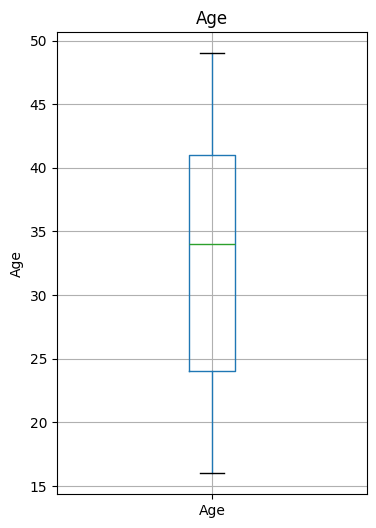

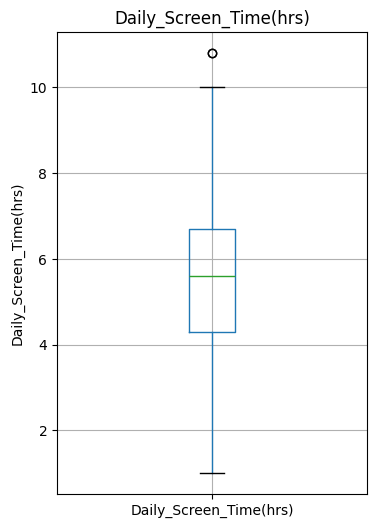

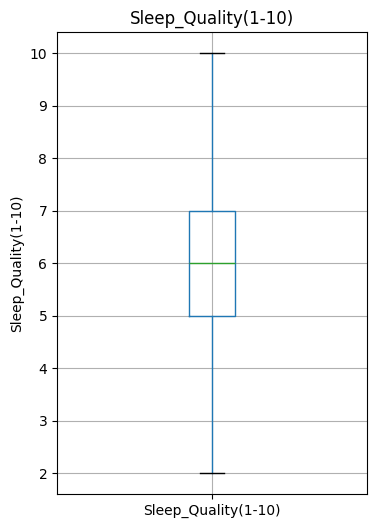

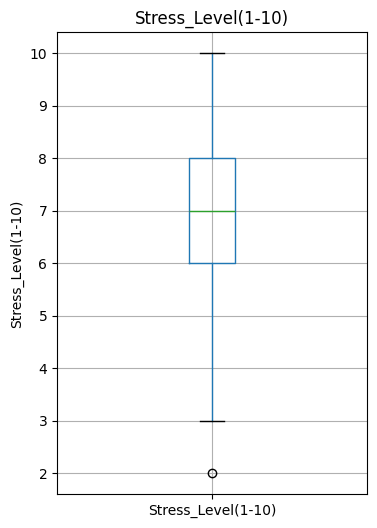

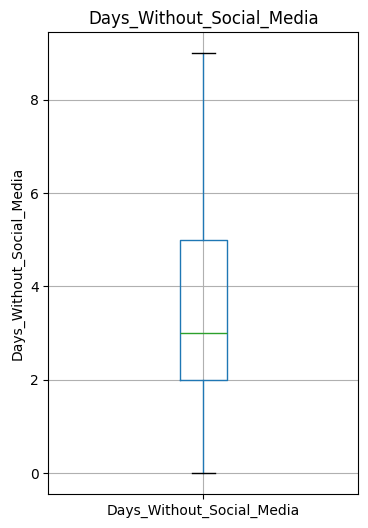

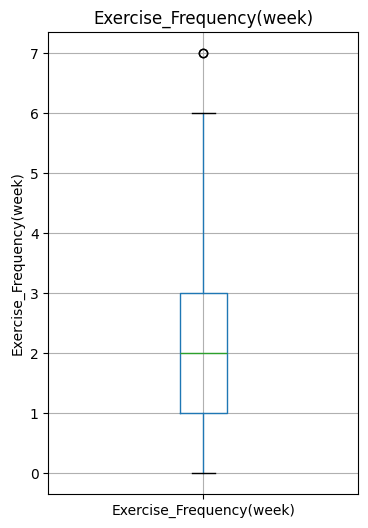

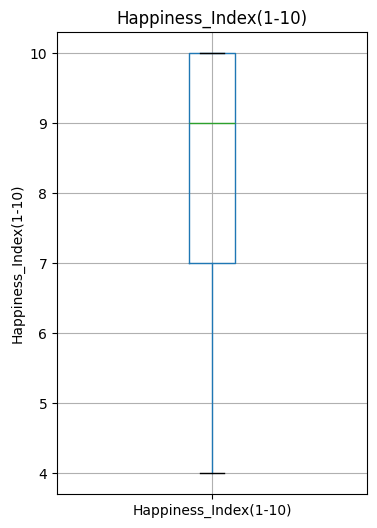

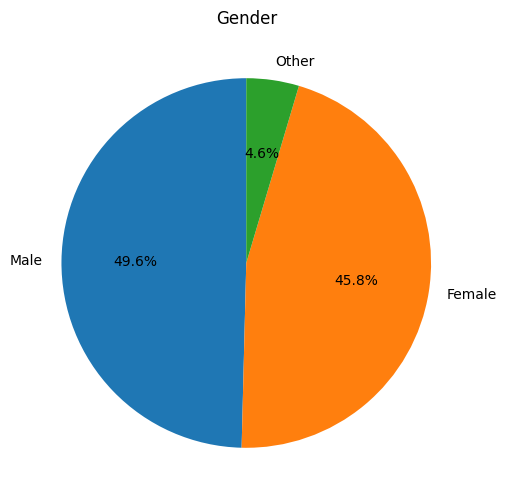

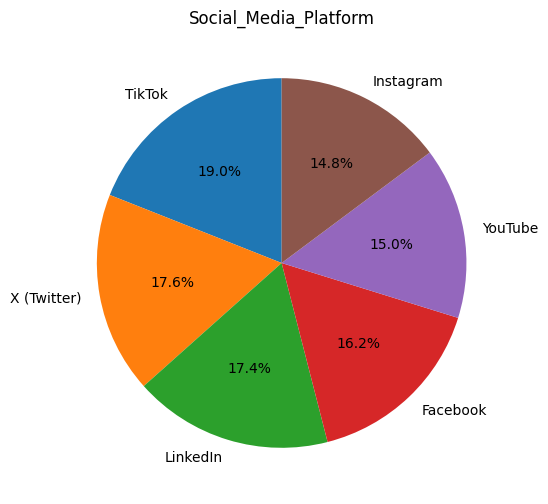

In [2]:
print('data_type:\n', df.dtypes, '\n')
print('пропуски:\n', df.isna().sum(), '\n') # пропусков нет
print('описание\n', df.describe(include='all'), '\n')

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    plt.figure(figsize=(4, 6))
    df.boxplot(column=col)
    plt.title(col)
    plt.ylabel(col)
    plt.show()



plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Gender')
plt.ylabel("")
plt.show()


plt.figure(figsize=(6, 6))
df['Social_Media_Platform'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Social_Media_Platform')
plt.ylabel("")
plt.show()


In [3]:
df = pd.get_dummies(df, columns=['Gender'], dtype=bool, prefix='', prefix_sep='')
df = pd.get_dummies(df, columns=['Social_Media_Platform'], dtype=bool, prefix='', prefix_sep='')
df = df.drop(columns=['User_ID'])
df = df.replace({True: 1, False: 0})



numeric_cols = df.select_dtypes(include='number').columns
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df_scaled.head())



        Age  Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  Stress_Level(1-10)  \
0  0.848485                0.214286                0.625               0.500   
1  0.424242                0.418367                0.625               0.750   
2  0.212121                0.653061                0.500               0.625   
3  0.606061                0.479592                0.625               0.750   
4  0.545455                0.612245                0.250               0.625   

   Days_Without_Social_Media  Exercise_Frequency(week)  Happiness_Index(1-10)  \
0                   0.222222                  0.714286               1.000000   
1                   0.555556                  0.428571               1.000000   
2                   0.111111                  0.428571               0.333333   
3                   0.111111                  0.142857               0.666667   
4                   0.555556                  0.142857               0.666667   

   Female  Male  Other  Facebook

/tmp/ipython-input-2157824064.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


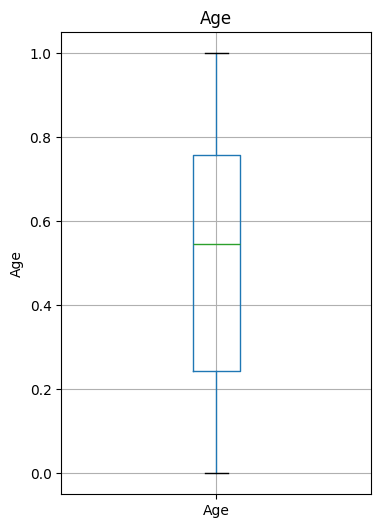

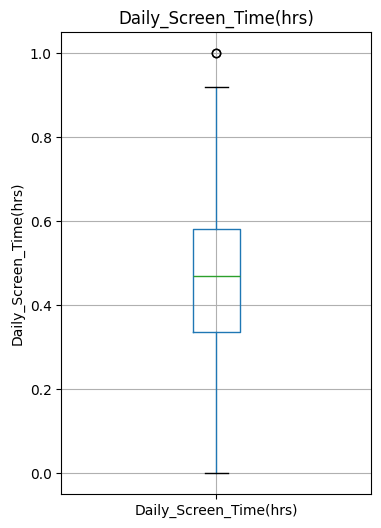

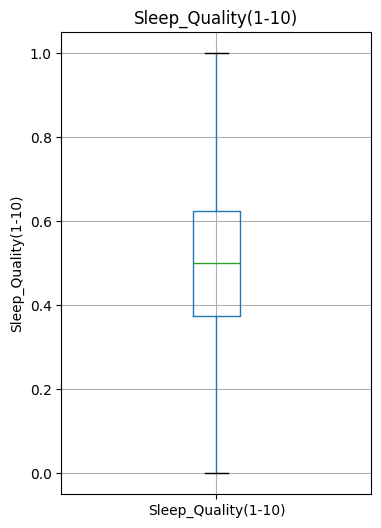

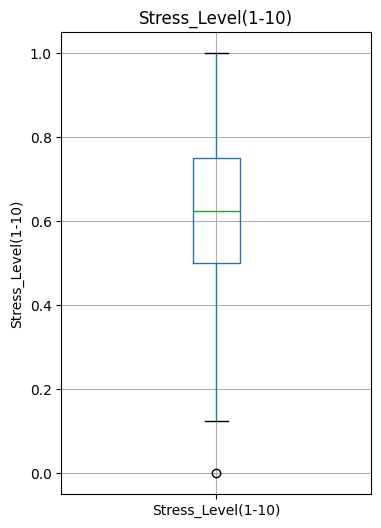

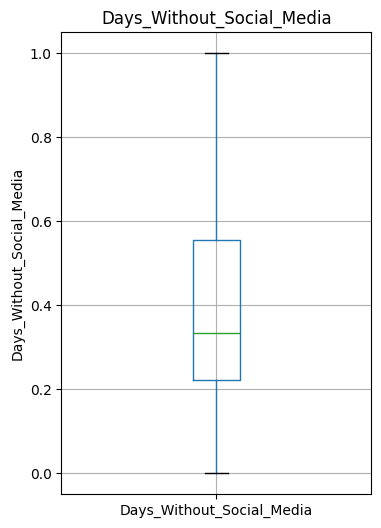

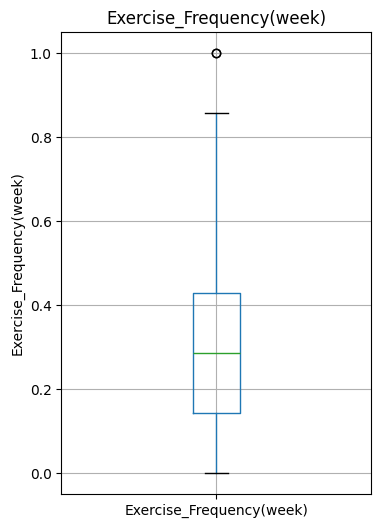

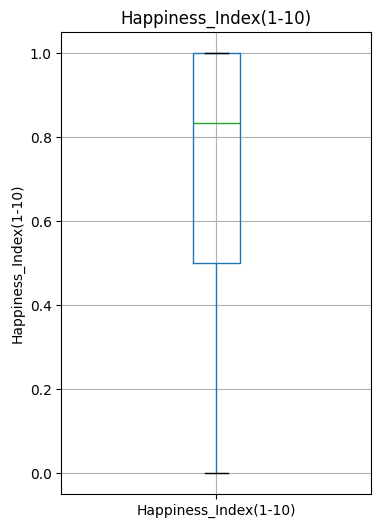

In [4]:
numeric_real_cols = [
    col for col in df_scaled.select_dtypes(include='number').columns
    if df_scaled[col].nunique() > 2]
for col in numeric_real_cols:
    plt.figure(figsize=(4, 6))
    df_scaled.boxplot(column=col)
    plt.title(col)
    plt.ylabel(col)
    plt.show()



In [9]:
X = df_scaled.drop(columns=['Happiness_Index(1-10)'])  # признаки
y = df_scaled['Happiness_Index(1-10)']                 # целевая переменная

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4)

In [10]:
print("1) Линейная регрессия \n")

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_train_pred = linreg.predict(X_train)
y_test_pred  = linreg.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred)) # Mean Absolute Error
print("Test  MAE:", mean_absolute_error(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred))) # корень из Mean Squared Error
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Train R^2:", r2_score(y_train, y_train_pred)) #Какой % вариации целевой переменной модель умеет объяснить.
print("Test  R^2:", r2_score(y_test, y_test_pred))


1) Линейная регрессия 

Train MAE: 0.12350484846025012
Test  MAE: 0.11520465796628915
Train RMSE: 0.15159719943624425
Test  RMSE: 0.14553109337799158
Train R^2: 0.64829052234868
Test  R^2: 0.6465371243648541


In [11]:
print("2) Ridge regression\n")

ridge = Ridge(alpha=0.01)
ridge.fit(X_train, y_train)

y_train_pred = ridge.predict(X_train)
y_test_pred  = ridge.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test  MAE:", mean_absolute_error(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test  R^2:", r2_score(y_test, y_test_pred))


2) Ridge regression

Train MAE: 0.1235001943087664
Test  MAE: 0.11521744182271294
Train RMSE: 0.1515972341429076
Test  RMSE: 0.1455464447556019
Train R^2: 0.6482903613079236
Test  R^2: 0.6464625502221328


In [13]:
print("3) Random Forest Regressor\n")

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test  MAE:", mean_absolute_error(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test  R^2:", r2_score(y_test, y_test_pred))


3) Random Forest Regressor

Train MAE: 0.04641874999999991
Test  MAE: 0.11077499999999996
Train RMSE: 0.06102220964078926
Test  RMSE: 0.14524373671713198
Train R^2: 0.94301276652275
Test  R^2: 0.6479315979787679
